# Side Experiment — Suffix-Trajectory Accept Comparison

Consumes per-step rows emitted by `simulation/evaluation/run_side_suffix_trajectory.py`.
Step advancement frame = **suffix-only** (`step += suffix_acc + 1`); at each visited step, accept length of eagle3 / suffix / extension(eagle3 backbone) / extension(suffix extension) is captured as a counterfactual at the same step_idx context.

## Metric definitions

- **accept tokens**: `sum(accepted)` per series (over the included step set).
- **accept rate**: `sum(accepted) / sum(tree_size_used)` per series — tree_size_used is the series-specific denominator recorded at each step.
- **MAT**: `sum(accepted) / n_steps` per series (mean accepted tokens per step).

Series → tree_size_used column mapping:

| Series | accept column | tree_size column |
|---|---|---|
| eagle3 | `eagle3_acc` | `eagle3_tree_size` |
| suffix | `suffix_acc` | `suffix_tree_size` |
| extension_backbone | `ext_acc_base` | `ext_base_size` |
| extension_sfx | `ext_acc_sfx` | `ext_tree_size_total - ext_base_size` |
| extension_total | `ext_acc_base + ext_acc_sfx` | `ext_tree_size_total` |

## Section 0 — Setup & prereq smoke

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Edit this to point at the per-step JSONL produced by
# run_side_suffix_trajectory.py.
PER_STEP = Path(
    # '../results/side_suffix_trajectory/qwen3_14b/bfcl_v4_steps6_topk8_b128_req576-578/B128/per_step.jsonl'
    '../results/side_suffix_trajectory/qwen3_8b/bfcl_v4_steps8_topk16_b128_req576-578/B128/per_step.jsonl'
)
META = PER_STEP.with_name('meta.json')

df = pd.read_json(PER_STEP, lines=True)
meta = json.loads(META.read_text()) if META.exists() else {}

# Derived columns used throughout the notebook.
df['ext_acc_total'] = df['ext_acc_base'] + df['ext_acc_sfx']
df['ext_sfx_tree_size'] = (df['ext_tree_size_total'] - df['ext_base_size'])

print(f'Rows: {len(df)}')
print(f'Requests: {df.request_id.nunique()}')
print(f'Meta: {json.dumps(meta, indent=2) if meta else "(none)"}')

Rows: 1296
Requests: 2
Meta: {
  "script": "run_side_suffix_trajectory",
  "agent_results_path": "/workspace/simulation/results/qwen3_8b/bfcl_v4_steps8_topk16_b128_req576-578/agent_results_eagle3.json",
  "suffix_drafts_path": "/workspace/simulation/results/qwen3_8b/bfcl_v4_steps8_topk16_b128_req576-578/suffix_drafts.jsonl",
  "model": "Qwen/Qwen3-8B",
  "budget": 128,
  "req_start": null,
  "req_end": null,
  "dataset_path": null,
  "responses_path": null,
  "verify": false,
  "n_requests": 2,
  "n_calls": 4,
  "n_steps_visited": 1296,
  "n_steps_with_ext_growth": 1296,
  "created_at": "2026-04-24T00:03:53.027714+00:00"
}


In [2]:
# --- Prereq assertion ---
# Static guarantee: run_tree_oracle_sim.py:1031 uses `for node_idx in
# range(n)` so root (node_idx=0) is always an anchor for suffix
# extension. Runtime proxy: at least some visited step must have seen
# the extended tree grow beyond the base.
n_grown = (df['ext_tree_size_total'] > df['ext_base_size']).sum()
assert n_grown > 0, (
    'ext_tree_size_total never exceeded ext_base_size — extension '
    'pathway appears inert. Check suffix cache warming or the artifact.'
)
print(f'OK — {n_grown}/{len(df)} visited steps had extension growth.')

OK — 1296/1296 visited steps had extension growth.


In [ ]:
# --- Invariant: extension_total >= suffix_acc ---
# After the virtual-root-extension patch to `_extension_step`,
# suffix's root-level predictions are grafted as root-children of
# the extended tree (alongside eagle3's root-children). This
# should make the greedy walk ALWAYS at least match single:suffix's
# accept at the same step, modulo cache-state micro-differences
# and tree-size truncation edge cases.
df['ext_acc_total_chk'] = df['ext_acc_base'] + df['ext_acc_sfx']
viol = df[df['ext_acc_total_chk'] < df['suffix_acc']]
print(f'Invariant ext_total >= suffix_acc: '
      f'{len(df) - len(viol)}/{len(df)} rows hold '
      f'({len(viol)} violations = {100 * len(viol) / max(len(df), 1):.2f}%)')
if len(viol):
    print('\nExamples:')
    print(viol[['request_id', 'call_idx', 'step_idx',
                'suffix_acc', 'ext_acc_base', 'ext_acc_sfx',
                'ext_acc_total_chk']].head())

In [3]:
def compute_metrics(sub, series_columns):
    """Return dict[series] -> dict(tokens, rate, mat) over `sub` frame.

    series_columns maps series_name -> (accept_col, tree_size_col).
    tree_size_col can be None to skip accept_rate for that series.
    """
    out = {}
    n = len(sub)
    for name, (acc_col, sz_col) in series_columns.items():
        acc_sum = int(sub[acc_col].sum())
        sz_sum = int(sub[sz_col].sum()) if sz_col else None
        out[name] = {
            'accept_tokens': acc_sum,
            'accept_rate': (acc_sum / sz_sum) if sz_sum else float('nan'),
            'mat': acc_sum / n if n else float('nan'),
            'n_steps': n,
        }
    return out


def bar_metric(metrics, metric_key, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 3.5))
    names = list(metrics.keys())
    vals = [metrics[n][metric_key] for n in names]
    _palette = {
        'eagle3':             '#4c72b0',
        'suffix':             '#dd8452',
        'extension_backbone': '#55a467',
        'extension_sfx':      '#c44e52',
        'extension_total':    '#8172b2',
    }
    colors = [_palette.get(n, '#888') for n in names]
    ax.bar(names, vals, color=colors)
    ax.set_title(title)
    ax.set_ylabel(metric_key)
    for i, v in enumerate(vals):
        if not np.isnan(v):
            ax.text(i, v, f'{v:.3f}' if metric_key != 'accept_tokens' else f'{int(v)}',
                    ha='center', va='bottom', fontsize=9)
    ax.tick_params(axis='x', rotation=15)
    return ax


def bar_metric_ext_stacked(metrics, metric_key, title, ax=None,
                           non_ext_series=('eagle3', 'suffix')):
    """Bar chart with extension as a stacked column (backbone + sfx).

    `non_ext_series`: iterable of series names shown as individual bars
    *before* the stacked extension column. Extension reads the keys
    `extension_backbone` (bottom) and `extension_sfx` (top) from
    `metrics`. Used by all three experiments — Exp 1 passes the default
    (eagle3, suffix); Exp 2/3 pass ('suffix',).
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 3.5))
    colors_non_ext = {'eagle3': '#4c72b0', 'suffix': '#dd8452'}
    non_ext = list(non_ext_series)
    vals = [metrics[n][metric_key] for n in non_ext]
    bb = metrics['extension_backbone'][metric_key]
    sx = metrics['extension_sfx'][metric_key]
    xs = np.arange(len(non_ext) + 1)
    for i, name in enumerate(non_ext):
        ax.bar(xs[i], vals[i], color=colors_non_ext.get(name, '#888'))
    ax.bar(xs[-1], bb, color='#55a467', label='backbone')
    ax.bar(xs[-1], sx, bottom=bb, color='#c44e52', label='sfx')
    ax.set_xticks(xs)
    ax.set_xticklabels(non_ext + ['extension'])
    ax.set_title(title)
    ax.set_ylabel(metric_key)
    fmt = (lambda v: f'{int(v)}') if metric_key == 'accept_tokens' else (lambda v: f'{v:.3f}')
    for i, v in enumerate(vals):
        if not np.isnan(v):
            ax.text(xs[i], v, fmt(v), ha='center', va='bottom', fontsize=9)
    if bb > 0:
        ax.text(xs[-1], bb / 2, fmt(bb), ha='center', va='center',
                fontsize=8, color='white')
    if sx > 0:
        ax.text(xs[-1], bb + sx / 2, fmt(sx), ha='center', va='center',
                fontsize=8, color='white')
    total = bb + sx
    if not np.isnan(total):
        ax.text(xs[-1], total, fmt(total), ha='center', va='bottom', fontsize=9)
    ax.legend(loc='upper right', fontsize=8)
    return ax


## Section 1 — Experiment 1: all steps, 4 series

`eagle3` · `suffix` · `extension_backbone` · `extension_sfx`

In [4]:
series_4 = {
    'eagle3':              ('eagle3_acc',   'eagle3_tree_size'),
    'suffix':              ('suffix_acc',   'suffix_tree_size'),
    'extension_backbone':  ('ext_acc_base', 'ext_base_size'),
    'extension_sfx':       ('ext_acc_sfx',  'ext_sfx_tree_size'),
}
m1 = compute_metrics(df, series_4)
pd.DataFrame(m1).T

,accept_tokens,accept_rate,mat,n_steps
eagle3,3270.0,0.019871,2.523148,1296.0
suffix,932.0,0.135761,0.719136,1296.0
extension_backbone,3270.0,0.019871,2.523148,1296.0
extension_sfx,1018.0,0.001802,0.785494,1296.0


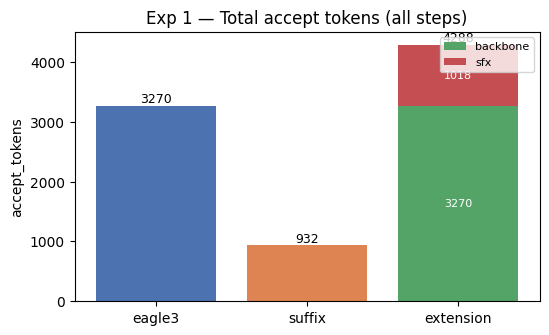

In [5]:
bar_metric_ext_stacked(m1, 'accept_tokens', 'Exp 1 — Total accept tokens (all steps)');

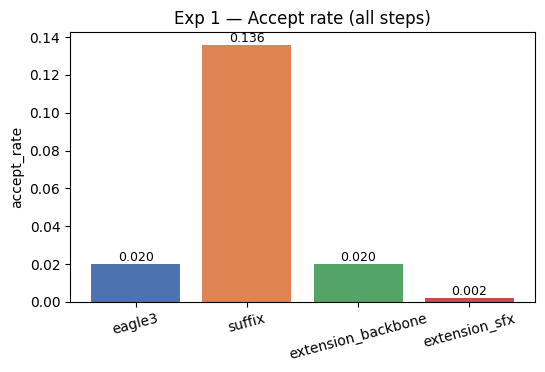

In [6]:
bar_metric(m1, 'accept_rate', 'Exp 1 — Accept rate (all steps)');

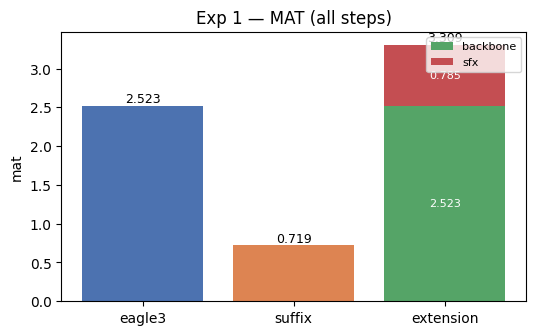

In [7]:
bar_metric_ext_stacked(m1, 'mat', 'Exp 1 — MAT (all steps)');

## Section 2 — Experiment 2: filter `suffix_acc > 0`

`suffix` · `extension` (stacked: backbone + sfx) — tokens/MAT; 3-bar rate (`suffix` / `extension_backbone` / `extension_sfx`).

In [8]:
sub2 = df[df['suffix_acc'] > 0].copy()
print(f'Steps passing filter: {len(sub2)} / {len(df)}')
series_2_split = {
    'suffix':              ('suffix_acc',   'suffix_tree_size'),
    'extension_backbone':  ('ext_acc_base', 'ext_base_size'),
    'extension_sfx':       ('ext_acc_sfx',  'ext_sfx_tree_size'),
}
m2 = compute_metrics(sub2, series_2_split)
pd.DataFrame(m2).T

Steps passing filter: 340 / 1296


,accept_tokens,accept_rate,mat,n_steps
suffix,932.0,0.327592,2.741176,340.0
extension_backbone,937.0,0.021713,2.755882,340.0
extension_sfx,583.0,0.003714,1.714706,340.0


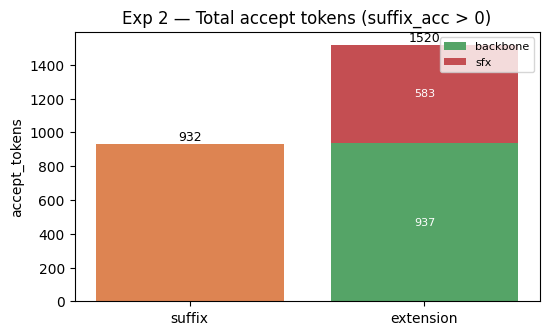

In [9]:
bar_metric_ext_stacked(m2, 'accept_tokens', 'Exp 2 — Total accept tokens (suffix_acc > 0)', non_ext_series=('suffix',));

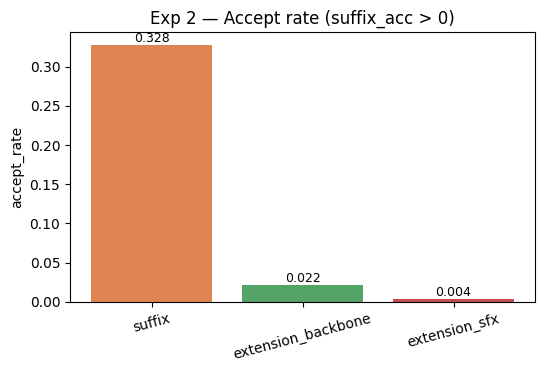

In [10]:
bar_metric(m2, 'accept_rate', 'Exp 2 — Accept rate (suffix_acc > 0)');

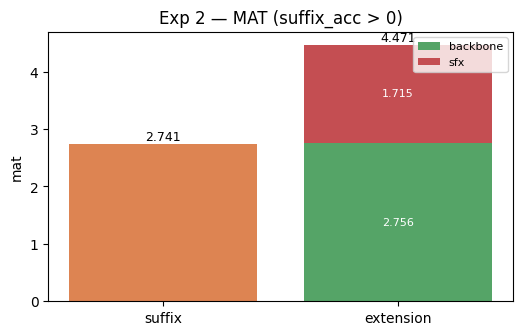

In [11]:
bar_metric_ext_stacked(m2, 'mat', 'Exp 2 — MAT (suffix_acc > 0)', non_ext_series=('suffix',));

In [ ]:
# Sample visualization — per-step accept for 4 series in a 500-step
# window around the first filtered step. Scoped to a single
# (request_id, call_idx) pair to avoid step_idx collisions across
# calls. Missing integer step_idx are positions that suffix-driven
# advancement skipped (advance > 1 at an earlier step); rendered as
# gray `x` markers at y=0.
#
# Series:
#   - eagle3_acc
#   - suffix_acc (drives trajectory)
#   - extension_total (= ext_acc_base + ext_acc_sfx)
#   - hybrid_oracle = max(eagle3_acc, suffix_acc) per step — the
#     best-of {eagle3, suffix} oracle at step_idx.
WINDOW_SIZE = 500
if len(sub2):
    counts = (sub2.groupby(['request_id', 'call_idx'])
                  .size().sort_values(ascending=False))
    sample_req, sample_call = counts.index[0]
    sample = (df[(df['request_id'] == sample_req)
                 & (df['call_idx'] == sample_call)]
              .sort_values('step_idx'))
    filt_sample = sample[sample['suffix_acc'] > 0]
    if len(filt_sample):
        center_step = int(filt_sample['step_idx'].iloc[0])
        lo = max(0, center_step - 2)
        hi = lo + WINDOW_SIZE
        window = sample[(sample['step_idx'] >= lo)
                        & (sample['step_idx'] < hi)].copy()
        window['hybrid_oracle'] = window[['eagle3_acc', 'suffix_acc']].max(axis=1)
        visited_steps = set(int(s) for s in window['step_idx'])
        skipped_steps = [s for s in range(lo, hi) if s not in visited_steps]
        fig, ax = plt.subplots(figsize=(16, 4.5))
        ax.plot(window['step_idx'], window['eagle3_acc'],
                marker='o', markersize=3, linewidth=1,
                color='#4c72b0', label='eagle3_acc', alpha=0.8)
        ax.plot(window['step_idx'], window['suffix_acc'],
                marker='o', markersize=3, linewidth=1,
                color='#dd8452', label='suffix_acc', alpha=0.8)
        ax.plot(window['step_idx'], window['ext_acc_total'],
                marker='s', markersize=3, linewidth=1,
                color='#55a467', label='extension_total', alpha=0.8)
        ax.plot(window['step_idx'], window['hybrid_oracle'],
                marker='D', markersize=3, linewidth=1,
                color='#8172b2', label='hybrid_oracle (max eagle3,suffix)',
                alpha=0.9)
        if skipped_steps:
            ax.scatter(skipped_steps, [0] * len(skipped_steps),
                       marker='x', color='lightgray', s=15,
                       label=f'skipped by suffix advance '
                             f'({len(skipped_steps)} positions)')
        ax.set_xlabel('step_idx')
        ax.set_ylabel('accepted tokens at step')
        ax.set_xlim(lo - 1, hi)
        ax.set_ylim(bottom=-0.5)
        ax.set_title(f'Exp 2 sample — request_id={sample_req!r} '
                     f'call_idx={sample_call} step_idx [{lo}, {hi})  '
                     f'visited={len(window)} / {WINDOW_SIZE}')
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(alpha=0.3)
    else:
        print('(sample has no suffix_acc > 0 steps in the chosen call)')
else:
    print('(no steps with suffix_acc > 0 — nothing to visualize)')

## Section 3 — Experiment 3: filter `suffix_acc == 0`

Same layout as Exp 2 — suffix bar is trivially 0 under this filter, the extension stack shows how much came from backbone vs sfx when suffix-only failed.

In [13]:
sub3 = df[df['suffix_acc'] == 0].copy()
print(f'Steps passing filter: {len(sub3)} / {len(df)}')
m3 = compute_metrics(sub3, series_2_split)
pd.DataFrame(m3).T

Steps passing filter: 956 / 1296


,accept_tokens,accept_rate,mat,n_steps
suffix,0.0,0.000000,0.000000,956.0
extension_backbone,2333.0,0.019216,2.440377,956.0
extension_sfx,435.0,0.001066,0.455021,956.0


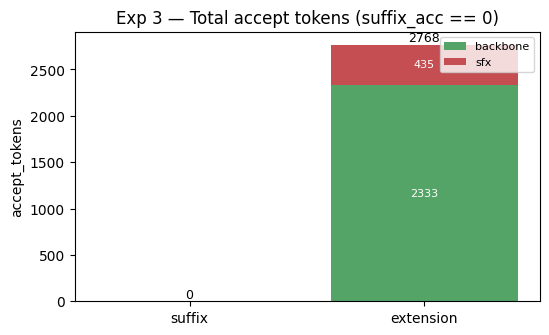

In [14]:
bar_metric_ext_stacked(m3, 'accept_tokens', 'Exp 3 — Total accept tokens (suffix_acc == 0)', non_ext_series=('suffix',));

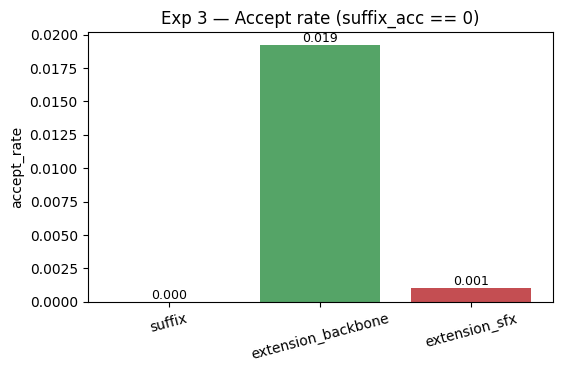

In [15]:
bar_metric(m3, 'accept_rate', 'Exp 3 — Accept rate (suffix_acc == 0)');

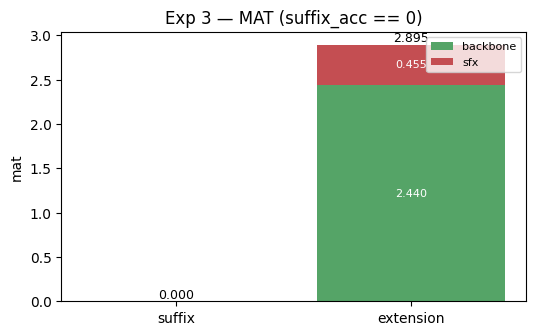

In [16]:
bar_metric_ext_stacked(m3, 'mat', 'Exp 3 — MAT (suffix_acc == 0)', non_ext_series=('suffix',));